# Parashikimi i Vendimeve të Punësimit - JobMatch

## 1. Analiza Eksploruese e të Dhënave (EDA)

# 1. Importimi i librarive

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '6'
# 1. Importimi i librarive te nevojshme
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Klasifikuesit (do te perdoren ne fazat e mevonshme)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Metrikat e vleresimit
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

In [2]:
# 2. Ngarkimi i te dhenave
df = pd.read_csv("../data/recruitment_data.csv")

In [3]:
# 3. Shikimi i rreshtave te pare dhe informacioni i dataset-it
print(df.shape)
print(df.head())
print(df.info())

# Kolonat e dataset-it (burimi: pershkrimi i datasetit ne Kaggle):
#
# Age                  - Mosha e kandidatit (20-50 vjec)
# Gender               - Gjinia (0 = mashkull, 1 = femer)
# EducationLevel       - Niveli i edukimit (ordinal):
#                        1 = Bachelor (cikli i pare), 2 = Bachelor (cikli i dyte),
#                        3 = Master, 4 = PhD
# ExperienceYears      - Vitet e pervojes se punes (0-15)
# PreviousCompanies    - Numri i kompanive ku ka punuar me pare (1-5)
# DistanceFromCompany  - Distanca e vendbanimit nga kompania ne km (1-50, e vazhdueshme)
# InterviewScore       - Piket e intervistes (0-100)
# SkillScore           - Piket e vleresimit te aftesive teknike (0-100)
# PersonalityScore     - Piket e vleresimit te personalitetit (0-100)
# RecruitmentStrategy  - Strategjia e ekipit te rekrutimit (kategorike nominale):
#                        1 = Agresive, 2 = E moderuar, 3 = Konservative
# HiringDecision       - [TARGET] Vendimi i punesimit:
#                        1 = punesohet, 0 = nuk punesohet

(1500, 11)
   Age  Gender  EducationLevel  ExperienceYears  PreviousCompanies  \
0   26       1               2                0                  3   
1   39       1               4               12                  3   
2   48       0               2                3                  2   
3   34       1               2                5                  2   
4   30       0               1                6                  1   

   DistanceFromCompany  InterviewScore  SkillScore  PersonalityScore  \
0            26.783828              48          78                91   
1            25.862694              35          68                80   
2             9.920805              20          67                13   
3             6.407751              36          27                70   
4            43.105343              23          52                85   

   RecruitmentStrategy  HiringDecision  
0                    1               1  
1                    2               1  
2           

In [4]:
# 4. Verifikimi i cilesise se te dhenave (missing values dhe duplikate)
print("Vlera te munguara per kolone:")
print(df.isnull().sum())
print(f"\nNumri i rreshtave duplikate: {df.duplicated().sum()}")

Vlera te munguara per kolone:
Age                    0
Gender                 0
EducationLevel         0
ExperienceYears        0
PreviousCompanies      0
DistanceFromCompany    0
InterviewScore         0
SkillScore             0
PersonalityScore       0
RecruitmentStrategy    0
HiringDecision         0
dtype: int64

Numri i rreshtave duplikate: 0


In [5]:
# 5. Analiza statistikore pershkruese
df.describe()

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,35.148667,0.492000,2.188000,7.694000,3.00200,25.505379,50.564000,51.116000,49.387333,1.893333,0.310000
std,9.252728,0.500103,0.862449,4.641414,1.41067,14.567151,28.626215,29.353563,29.353201,0.689642,0.462647
min,20.000000,0.000000,1.000000,0.000000,1.00000,1.031376,0.000000,0.000000,0.000000,1.000000,0.000000
25%,27.000000,0.000000,2.000000,4.000000,2.00000,12.838851,25.000000,25.750000,23.000000,1.000000,0.000000
50%,35.000000,0.000000,2.000000,8.000000,3.00000,25.502239,52.000000,53.000000,49.000000,2.000000,0.000000
75%,43.000000,1.000000,3.000000,12.000000,4.00000,37.737996,75.000000,76.000000,76.000000,2.000000,1.000000
max,50.000000,1.000000,4.000000,15.000000,5.00000,50.992462,100.000000,100.000000,100.000000,3.000000,1.000000


HiringDecision
0    1035
1     465
Name: count, dtype: int64
HiringDecision
0    0.69
1    0.31
Name: proportion, dtype: float64


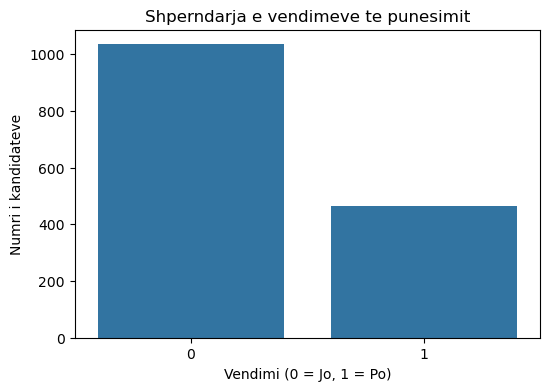

In [6]:
# 6. Shperndarja e variables target (HiringDecision)
print(df['HiringDecision'].value_counts())
print(df['HiringDecision'].value_counts(normalize=True).round(3))

plt.figure(figsize=(6, 4))
sns.countplot(x='HiringDecision', data=df)
plt.title('Shperndarja e vendimeve te punesimit')
plt.xlabel('Vendimi (0 = Jo, 1 = Po)')
plt.ylabel('Numri i kandidateve')
plt.show()

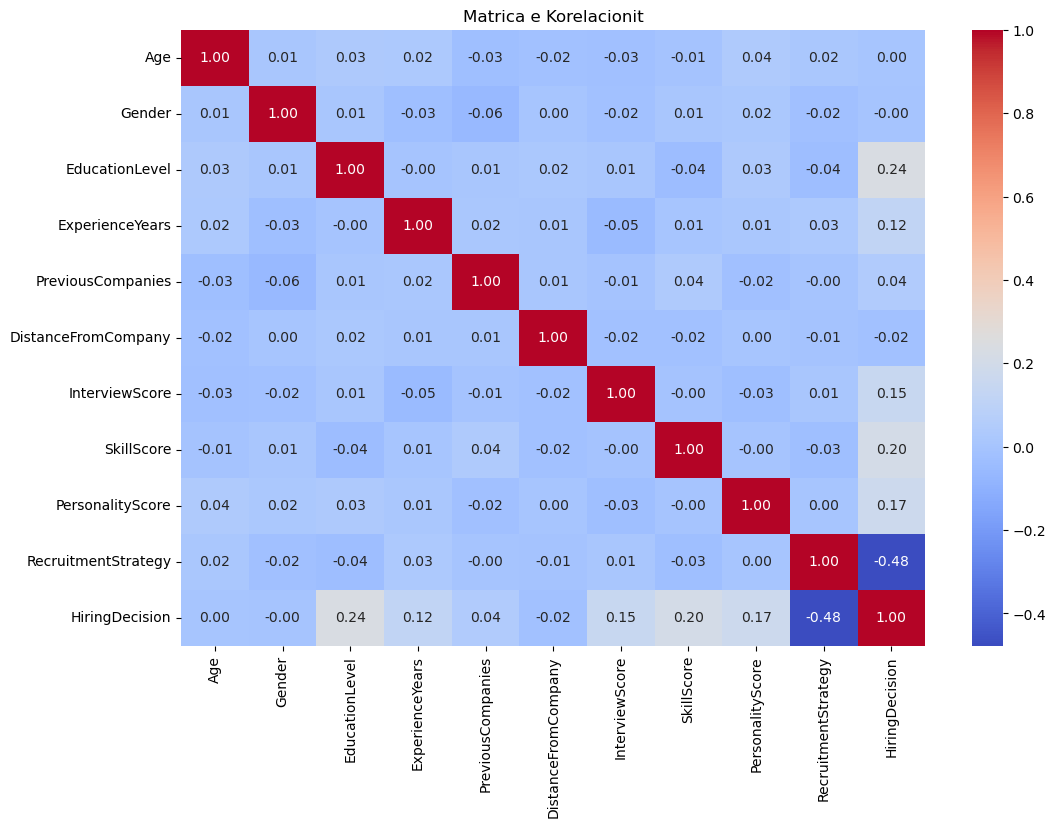

In [7]:
# 7. Matrica e korelacionit
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrica e Korelacionit')
plt.show()

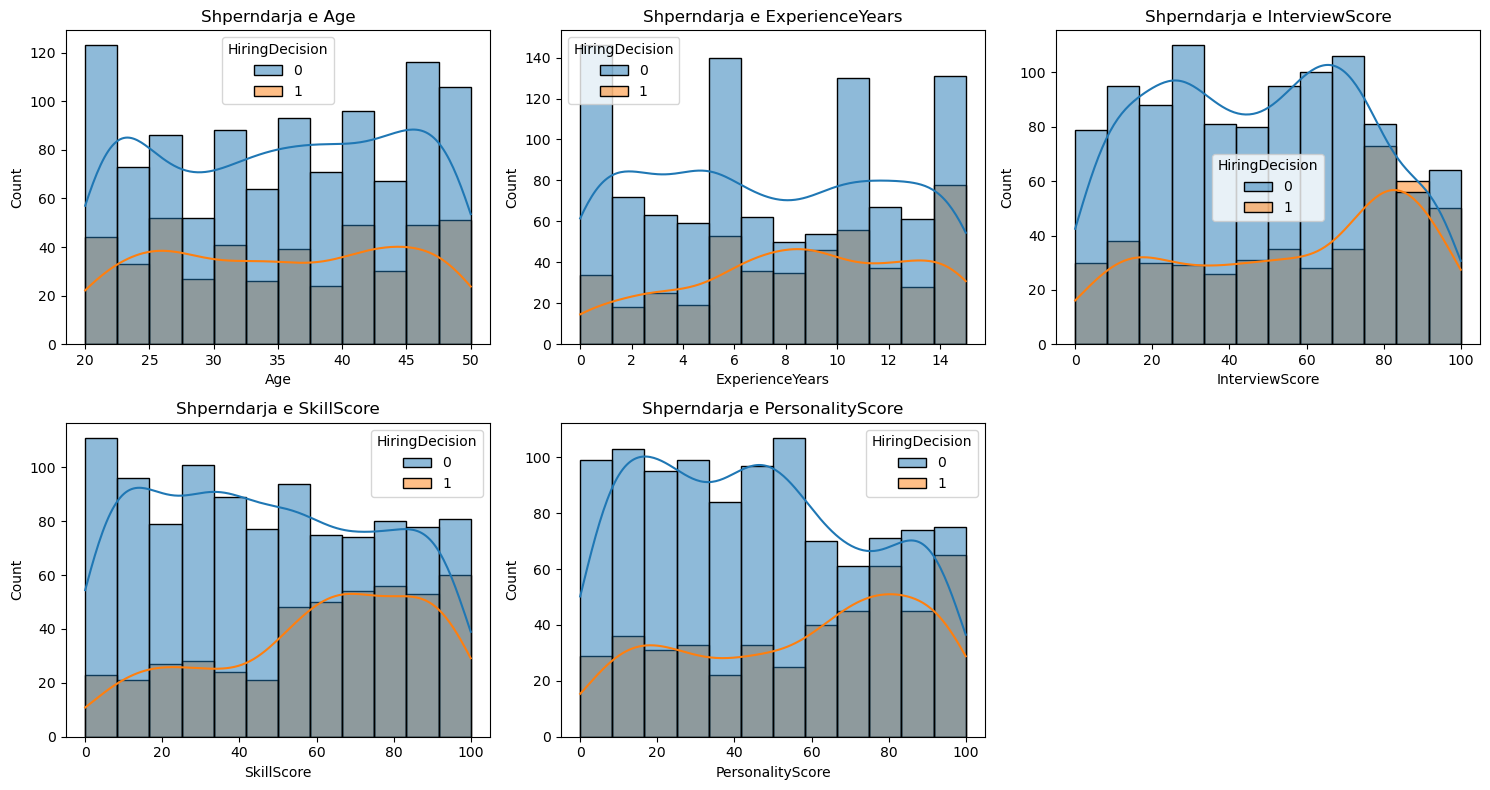

In [8]:
# 8. Shperndarja e veçorive numerike sipas vendimit te punesimit
features_num = ['Age', 'ExperienceYears', 'InterviewScore', 'SkillScore', 'PersonalityScore']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), features_num):
    sns.histplot(data=df, x=col, hue='HiringDecision', kde=True, ax=ax)
    ax.set_title(f'Shperndarja e {col}')
axes.flatten()[-1].axis('off')  
plt.tight_layout()
plt.show()

## 2. Parapërpunimi i të Dhënave

In [9]:
# Permbledhje e gjetjeve nga EDA
# 
# 1. Dataseti ka 1500 rreshta dhe 11 kolona, te gjitha numerike.
#    Nuk ka vlera te munguara dhe as rreshta duplikate.
#
# 2. Variabla target (HiringDecision) eshte e pabalancuar: 69% e kandidateve
#    nuk punesohen (klasa 0) dhe 31% punesohen (klasa 1). Per kete arsye:
#    - Ndarja train/test do te behet me stratifikim (stratify=y)
#    - Krahas accuracy do te raportojme precision, recall dhe F1-score,
#      sepse accuracy e vetme mund të jete mashtruese me klasa te pabalancuara.
#
# 3. Vecorite kane shkalle shume te ndryshme (p.sh. Age 20-50, scores 0-100,
#    EducationLevel 1-4). Kjo e ben standardizimin (StandardScaler) të
#    domosdoshem per algoritmet e bazuara në distance (KNN) dhe rrjetat neurale.
#
# 4. Nga matrica e korelacionit, RecruitmentStrategy ka lidhjen me te forte
#    me HiringDecision (-0.48), e ndjekur nga EducationLevel (0.24),
#    SkillScore (0.20), PersonalityScore (0.17), InterviewScore (0.15)
#    dhe ExperienceYears (0.12).
#    Age, Gender, PreviousCompanies dhe DistanceFromCompany kane korelacion
#    pothuajse zero - kandidate kryesore per tu hequr ne fazen e feature
#    selection.

In [10]:
# 10. Ndarja e te dhenave ne X (veçorite) dhe y (target)
X = df.drop(columns=['HiringDecision'])
y = df['HiringDecision']

# One-Hot Encoding për RecruitmentStrategy
# Kjo variabel eshte kategorike nominale (1=Agresive, 2=Mesatare, 3=Konservative)
# Vlerat numerike nuk kane renditje kuptimplote, prandaj e kthejme ne kolona binare
# EducationLevel e leme ordinal, sepse ka renditje natyrale (1 < 2 < 3 < 4)
X = pd.get_dummies(X, columns=['RecruitmentStrategy'], prefix='Strategy', drop_first=False)
X = X.astype(float)

print(X.columns.tolist())
print(X.shape)

['Age', 'Gender', 'EducationLevel', 'ExperienceYears', 'PreviousCompanies', 'DistanceFromCompany', 'InterviewScore', 'SkillScore', 'PersonalityScore', 'Strategy_1', 'Strategy_2', 'Strategy_3']
(1500, 12)


In [11]:
# 11. Ndarja ne bashkesi trajnimi dhe testimi (80/20, me stratifikim)
# stratify=y siguron qe raporti 69/31 i klasave te ruhet ne te dyja bashkesite
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Trajnim: {X_train.shape[0]} rreshta")
print(f"Testim:  {X_test.shape[0]} rreshta")
print(f"\nRaporti i klasave ne trajnim:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nRaporti i klasave ne testim:\n{y_test.value_counts(normalize=True).round(3)}")

Trajnim: 1200 rreshta
Testim:  300 rreshta

Raporti i klasave ne trajnim:
HiringDecision
0    0.69
1    0.31
Name: proportion, dtype: float64

Raporti i klasave ne testim:
HiringDecision
0    0.69
1    0.31
Name: proportion, dtype: float64


In [12]:
# 12. Standardizimi i veçorive me StandardScaler
# E RENDESISHME: scaler-i ben fit VETEM mbi te dhenat e trajnimit,
# pastaj transformon te dyja bashkesite. Kjo shmang "data leakage" -
# rrjedhjen e informacionit nga testimi ne trajnim.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Versionet e pa-skaluara (X_train, X_test) i ruajme gjithashtu,
# sepse algoritmet e bazuara ne peme nuk kane nevoje per scaling
# dhe do t'i përdorim per nje krahasim me/pa scaling te KNN

## 3. Klasifikimi

In [13]:
# 13. Funksion ndihmes per vleresimin e klasifikuesve
# Llogarit metrikat kryesore dhe vizualizon matricen e konfuzionit
rezultatet = {}  # ketu ruajme rezultatet e te gjithe klasifikuesve per tabelen krahasuese

def vlereso_klasifikuesin(emri, model, X_test_input, y_test):
    y_pred = model.predict(X_test_input)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    rezultatet[emri] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    
    print(f"--- {emri} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Jo (0)', 'Po (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'Matrica e Konfuzionit - {emri}')
    plt.show()
    
    return y_pred

### 3.1 KNN

In [14]:
# 14. Klasifikuesi 1: K-Nearest Neighbors
# Rregullimi i hiperparametrave me GridSearchCV (5-fold cross-validation)
# Hiperparametrat e testuar:
#   - n_neighbors: numri i fqinjeve me te afert (3 deri 21)
#   - weights: 'uniform' (te gjithe fqinjet peshojne njesoj) ose
#              'distance' (fqinjet me te afert peshojne me shume)
#   - metric: menyra e llogaritjes se distances

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='f1',   # F1 si metrike optimizimi per shkak te klasave te pabalancuara
    n_jobs=-1
)
grid_knn.fit(X_train_scaled, y_train)

print(f"Hiperparametrat me te mire: {grid_knn.best_params_}")
print(f"F1-score mesatar ne cross-validation: {grid_knn.best_score_:.4f}")

Hiperparametrat me te mire: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
F1-score mesatar ne cross-validation: 0.7615


--- KNN ---
Accuracy:  0.8733
Precision: 0.8571
Recall:    0.7097
F1-Score:  0.7765


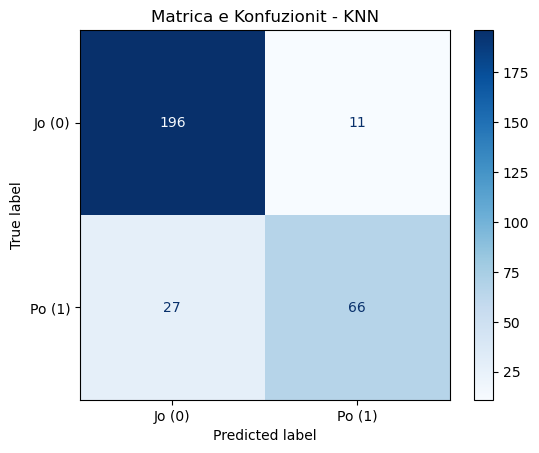

In [15]:
# 15. Vleresimi i KNN ne bashkesine e testimit
y_pred_knn = vlereso_klasifikuesin('KNN', grid_knn.best_estimator_, X_test_scaled, y_test)

In [16]:
# 16. Eksperiment: KNN pa standardizim te te dhenave
# Qellimi: te demonstrojme pse scaling eshte i domosdoshem per algoritmet
# e bazuara ne distance. Pa scaling, veçorite me shkalle te madhe
# (p.sh. scores 0-100) dominojne mbi ato me shkalle te vogel (EducationLevel 1-4)
knn_pa_scaling = KNeighborsClassifier(**grid_knn.best_params_)
knn_pa_scaling.fit(X_train, y_train)
y_pred_pa = knn_pa_scaling.predict(X_test)

print(f"F1-Score ME scaling:  {rezultatet['KNN']['F1-Score']:.4f}")
print(f"F1-Score PA scaling:  {f1_score(y_test, y_pred_pa):.4f}")

F1-Score ME scaling:  0.7765
F1-Score PA scaling:  0.4472


### 3.2 Decision Tree

In [17]:
# 17. Klasifikuesi 2: Decision Tree 
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       param_grid_dt, cv=5, scoring='f1', n_jobs=-1)
grid_dt.fit(X_train, y_train)   # pemet nuk kane nevoje per scaling

print(f"Hiperparametrat me te mire: {grid_dt.best_params_}")
print(f"F1-score ne cross-validation: {grid_dt.best_score_:.4f}")

Hiperparametrat me te mire: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}
F1-score ne cross-validation: 0.8420


--- Decision Tree ---
Accuracy:  0.9167
Precision: 0.9474
Recall:    0.7742
F1-Score:  0.8521


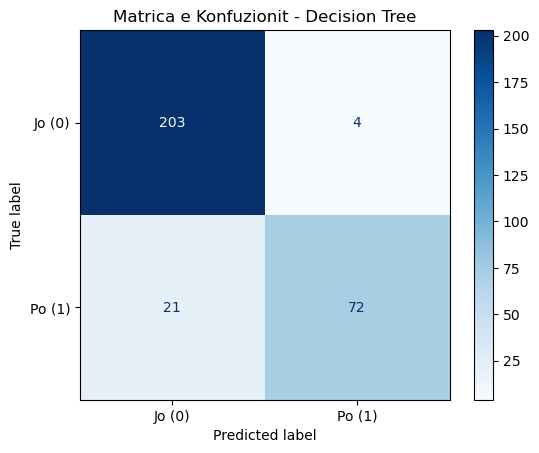

In [18]:
# 18. Vleresimi i Decision Tree ne bashkesine e testimit
y_pred_dt = vlereso_klasifikuesin('Decision Tree', grid_dt.best_estimator_, X_test, y_test)

### 3.3 Random Forest

In [19]:
# 19. Klasifikuesi 3: Random Forest 
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f"Hiperparametrat me te mire: {grid_rf.best_params_}")
print(f"F1-score ne cross-validation: {grid_rf.best_score_:.4f}")

Hiperparametrat me te mire: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
F1-score ne cross-validation: 0.8433


--- Random Forest ---
Accuracy:  0.9200
Precision: 0.9481
Recall:    0.7849
F1-Score:  0.8588


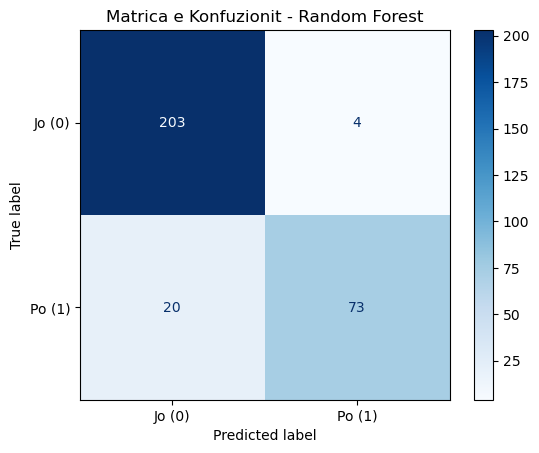

In [20]:
# 20. Vleresimi i Random Forest ne bashkesine e testimit
y_pred_rf = vlereso_klasifikuesin('Random Forest', grid_rf.best_estimator_, X_test, y_test)

### 3.4 Logistic Regression

In [21]:
# 21. Klasifikuesi 4: Logistic Regression (linear)
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000),
                       param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)   

print(f"Hiperparametrat me te mire: {grid_lr.best_params_}")
print(f"F1-score ne cross-validation: {grid_lr.best_score_:.4f}")

Hiperparametrat me te mire: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
F1-score ne cross-validation: 0.8016


--- Logistic Regression ---
Accuracy:  0.8700
Precision: 0.8462
Recall:    0.7097
F1-Score:  0.7719


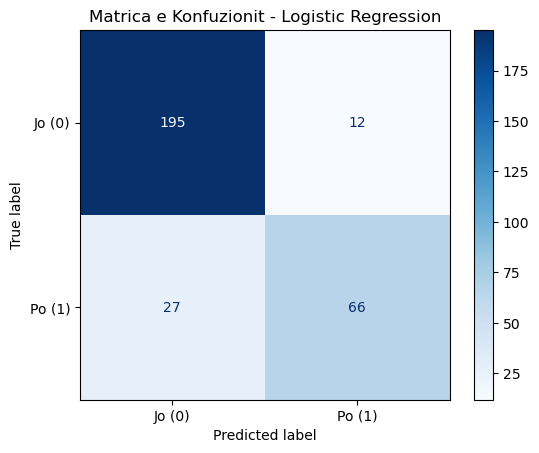

In [22]:
# 22. Vleresimi i Logistic Regression ne bashkesine e testimit
y_pred_lr = vlereso_klasifikuesin('Logistic Regression', grid_lr.best_estimator_, X_test_scaled, y_test)

## 4. Rrjeta Neurale (MLP)

--- MLP (64) ---
Accuracy:  0.8700
Precision: 0.8375
Recall:    0.7204
F1-Score:  0.7746


c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


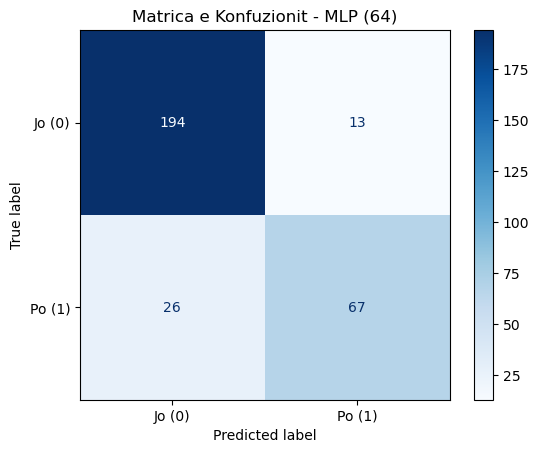

In [23]:
# 23. Klasifikuesi 5: Rrjete Neurale (MLP - Multi-Layer Perceptron)
# Arkitektura 1: nje shtrese e fshehur me 64 njesi, aktivizim ReLU
from sklearn.neural_network import MLPClassifier

mlp_1 = MLPClassifier(hidden_layer_sizes=(64,), activation='relu',
                      solver='adam', max_iter=500, random_state=42)
mlp_1.fit(X_train_scaled, y_train)

y_pred_mlp1 = vlereso_klasifikuesin('MLP (64)', mlp_1, X_test_scaled, y_test)

--- MLP (64, 32) ---
Accuracy:  0.8433
Precision: 0.7738
Recall:    0.6989
F1-Score:  0.7345


c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


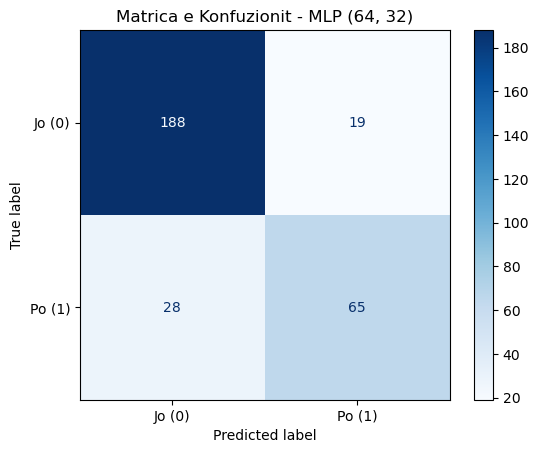

In [24]:
# 24. Arkitektura 2: dy shtresa te fshehura (64, 32), aktivizim ReLU
mlp_2 = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                      solver='adam', max_iter=500, random_state=42)
mlp_2.fit(X_train_scaled, y_train)

y_pred_mlp2 = vlereso_klasifikuesin('MLP (64, 32)', mlp_2, X_test_scaled, y_test)

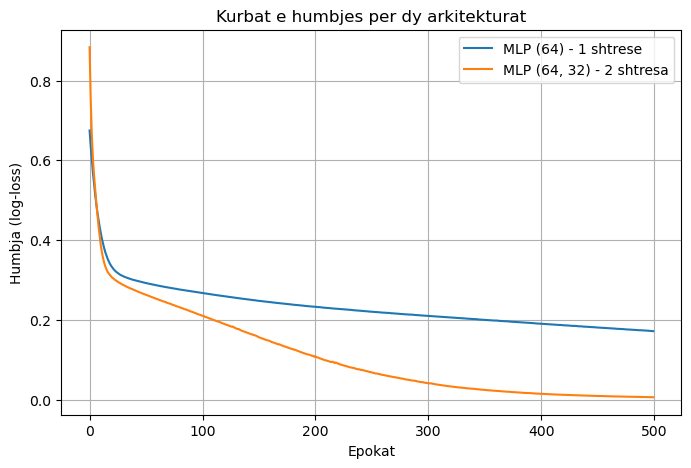

Epoka deri ne konvergjence - MLP (64):     500
Epoka deri ne konvergjence - MLP (64, 32): 500


In [25]:
# 25. Krahasimi i dy arkitekturave: kurbat e humbjes gjate trajnimit
plt.figure(figsize=(8, 5))
plt.plot(mlp_1.loss_curve_, label='MLP (64) - 1 shtrese')
plt.plot(mlp_2.loss_curve_, label='MLP (64, 32) - 2 shtresa')
plt.xlabel('Epokat')
plt.ylabel('Humbja (log-loss)')
plt.title('Kurbat e humbjes per dy arkitekturat')
plt.legend()
plt.grid(True)
plt.show()

print(f"Epoka deri ne konvergjence - MLP (64):     {mlp_1.n_iter_}")
print(f"Epoka deri ne konvergjence - MLP (64, 32): {mlp_2.n_iter_}")

In [26]:
# 26. Rregullimi i hiperparametrave per rrjeten neurale
param_grid_mlp = {
    'hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01]
}

grid_mlp = GridSearchCV(MLPClassifier(solver='adam', max_iter=1000, random_state=42,
                                      early_stopping=True),
                        param_grid_mlp, cv=5, scoring='f1', n_jobs=-1)
grid_mlp.fit(X_train_scaled, y_train)

print(f"Hiperparametrat me te mire: {grid_mlp.best_params_}")
print(f"F1-score ne cross-validation: {grid_mlp.best_score_:.4f}")

Hiperparametrat me te mire: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (64, 32)}
F1-score ne cross-validation: 0.7883


--- Rrjeta Neurale (MLP) ---
Accuracy:  0.8467
Precision: 0.7901
Recall:    0.6882
F1-Score:  0.7356


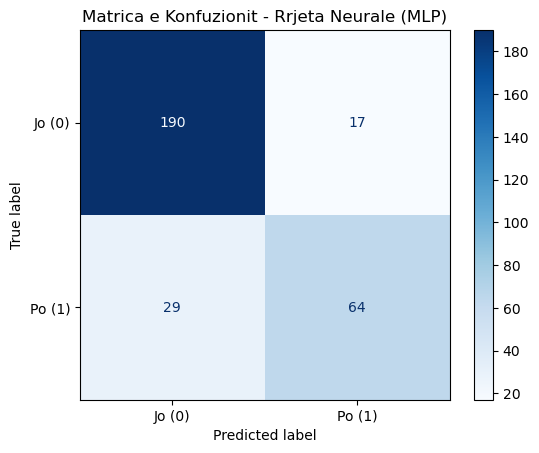

In [27]:
# 27. Vleresimi i rrjetes neurale me te mire ne bashkesine e testimit
y_pred_mlp = vlereso_klasifikuesin('Rrjeta Neurale (MLP)', grid_mlp.best_estimator_, X_test_scaled, y_test)

## 5. Zgjedhja e Veçorive (Feature Selection)

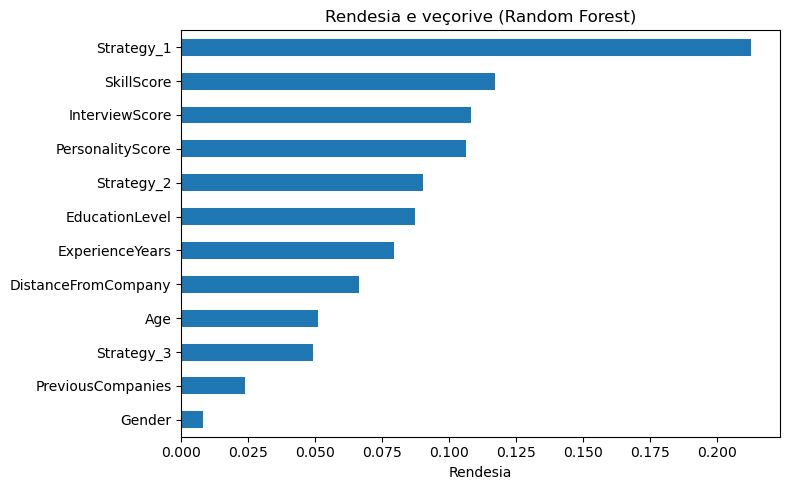

Strategy_1             0.2127
SkillScore             0.1170
InterviewScore         0.1083
PersonalityScore       0.1062
Strategy_2             0.0902
EducationLevel         0.0874
ExperienceYears        0.0795
DistanceFromCompany    0.0664
Age                    0.0510
Strategy_3             0.0491
PreviousCompanies      0.0239
Gender                 0.0083
dtype: float64


In [28]:
# 28. Rendesia e veçorive sipas Random Forest (modeli me i mire deri tani)
importances = pd.Series(grid_rf.best_estimator_.feature_importances_,
                        index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.title('Rendesia e veçorive (Random Forest)')
plt.xlabel('Rendesia')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances.round(4))

In [29]:
# 29. Eksperiment: ritrajnimi i Random Forest vetem me veçorite me te rendesishme
# Krahasojme: te gjitha 12 veçorite vs top-6 vs top-4
for k in [6, 4]:
    top_features = importances.head(k).index.tolist()
    
    rf_k = RandomForestClassifier(**grid_rf.best_params_, random_state=42)
    rf_k.fit(X_train[top_features], y_train)
    y_pred_k = rf_k.predict(X_test[top_features])
    
    print(f"Top-{k} vecori: {top_features}")
    print(f"  Accuracy: {accuracy_score(y_test, y_pred_k):.4f} | "
          f"F1: {f1_score(y_test, y_pred_k):.4f}\n")

print(f"Te gjitha 12 vecorite -> Accuracy: {rezultatet['Random Forest']['Accuracy']:.4f} | "
      f"F1: {rezultatet['Random Forest']['F1-Score']:.4f}")

Top-6 vecori: ['Strategy_1', 'SkillScore', 'InterviewScore', 'PersonalityScore', 'Strategy_2', 'EducationLevel']
  Accuracy: 0.8533 | F1: 0.7500

Top-4 vecori: ['Strategy_1', 'SkillScore', 'InterviewScore', 'PersonalityScore']
  Accuracy: 0.8333 | F1: 0.7093

Te gjitha 12 vecorite -> Accuracy: 0.9200 | F1: 0.8588


## 6. Grupimi me K-Means (Clustering)

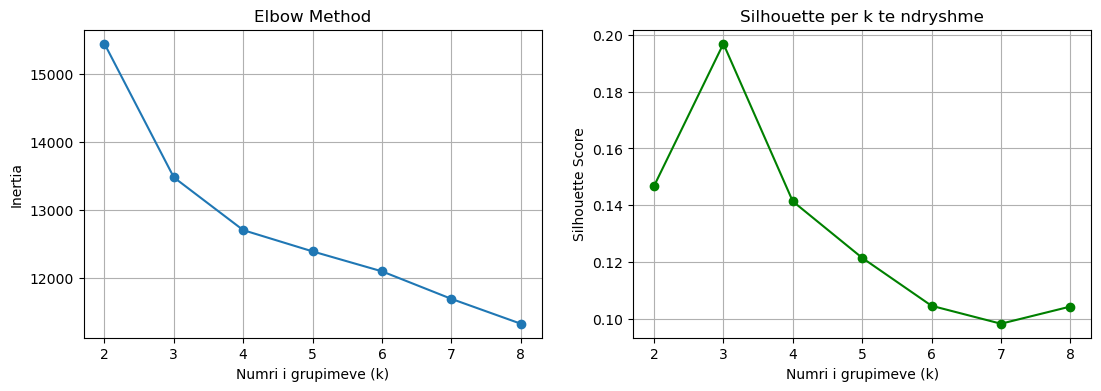

Silhouette scores: {2: 0.1467, 3: 0.1969, 4: 0.1413, 5: 0.1214, 6: 0.1045, 7: 0.0982, 8: 0.1043}


In [30]:
# 30. K-Means: zgjedhja e numrit te grupimeve (elbow method + silhouette)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

# Heqim etiketat - clustering punon pa to. Perdorim te dhenat e skaluara te plota
X_cluster = StandardScaler().fit_transform(X)

inertia, silhouettes = [], []
k_values = range(2, 9)
for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = km.fit_predict(X_cluster)
    inertia.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_values, inertia, 'o-')
axes[0].set_xlabel('Numri i grupimeve (k)'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method'); axes[0].grid(True)
axes[1].plot(k_values, silhouettes, 'o-', color='green')
axes[1].set_xlabel('Numri i grupimeve (k)'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette per k te ndryshme'); axes[1].grid(True)
plt.show()

print("Silhouette scores:", dict(zip(k_values, [round(s, 4) for s in silhouettes])))

Varianca e shpjeguar nga 2 komponentet: 25.37%


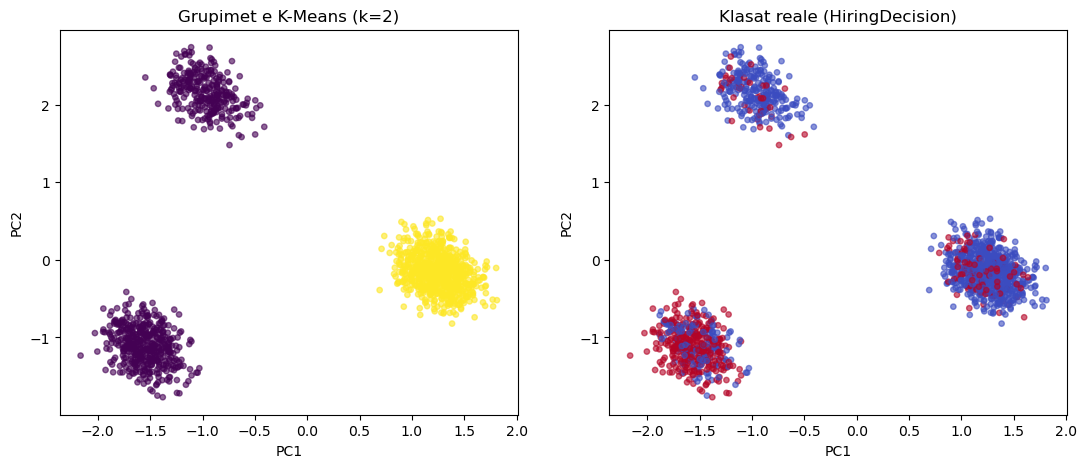

In [31]:
# 31. K-Means me k=2 (numri natyror i klasave) + vizualizim me PCA
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_cluster)

# PCA per reduktim ne 2 dimensione (vetem per vizualizim)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)
print(f"Varianca e shpjeguar nga 2 komponentet: {pca.explained_variance_ratio_.sum():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6, s=15)
axes[0].set_title('Grupimet e K-Means (k=2)')
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6, s=15)
axes[1].set_title('Klasat reale (HiringDecision)')
for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.show()

In [32]:
# 32. Krahasimi i grupimeve me klasat reale
crosstab = pd.crosstab(clusters, y, rownames=['Cluster'], colnames=['HiringDecision'])
print(crosstab)

ari = adjusted_rand_score(y, clusters)
print(f"\nAdjusted Rand Index: {ari:.4f}")
print("(0 = grupim i rastesishem ndaj klasave, 1 = perputhje e plote)")

HiringDecision    0    1
Cluster                 
0               370  360
1               665  105

Adjusted Rand Index: 0.1339
(0 = grupim i rastesishem ndaj klasave, 1 = perputhje e plote)


## 7. Krahasimi Final dhe Përfundimet

                      Accuracy  Precision  Recall  F1-Score
Random Forest           0.9200     0.9481  0.7849    0.8588
Decision Tree           0.9167     0.9474  0.7742    0.8521
KNN                     0.8733     0.8571  0.7097    0.7765
MLP (64)                0.8700     0.8375  0.7204    0.7746
Logistic Regression     0.8700     0.8462  0.7097    0.7719
Rrjeta Neurale (MLP)    0.8467     0.7901  0.6882    0.7356
MLP (64, 32)            0.8433     0.7738  0.6989    0.7345


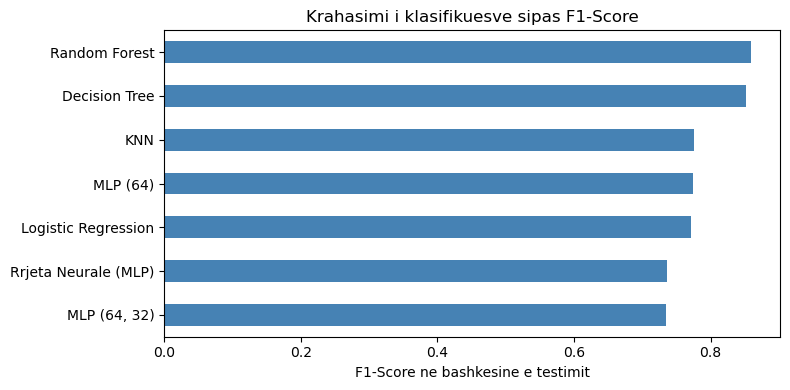

In [33]:
# 33. Tabela krahasuese e te gjithe klasifikuesve
tabela = pd.DataFrame(rezultatet).T.round(4)
tabela = tabela.sort_values('F1-Score', ascending=False)
print(tabela)

tabela['F1-Score'].plot(kind='barh', figsize=(8, 4), color='steelblue')
plt.xlabel('F1-Score ne bashkesine e testimit')
plt.title('Krahasimi i klasifikuesve sipas F1-Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Perfundimet kryesore

1. **Random Forest performoi me se miri** (F1 = 0.86, Accuracy = 0.92), i ndjekur ngushte
   nga Decision Tree. Modelet e bazuara ne peme i kapin me mire rregullat me pragje
   dhe nderveprimet mes vecorive qe karakterizojne vendimet e punesimit.

2. **Modelet lineare dhe te bazuara ne distance** (Logistic Regression, KNN) dhe
   **rrjeta neurale (MLP)** performuan ngjashem (F1 ≈ 0.73-0.78), nen pemet —
   dataset tabelar me rregulla diskrete favorizon qasjet e bazuara ne peme.

3. **Standardizimi ishte vendimtar per KNN**: pa te, F1 bie nga 0.78 ne 0.45.

4. **Reduktimi i veçorive nuk e permiresoi performancen** — vecorite jane te
   pakorreluara mes tyre dhe secila mbart informacion te pavarur.

5. **Rrjeta me e thelle nuk ishte me e mire**: pa rregullarizim, arkitektura (64, 32)
   overfit-onte; me early stopping behej konkurruese por pa e kaluar ate me te thjeshten.

6. **Clustering-u (K-Means) tregoi perputhje te dobet me klasat reale** (ARI = 0.13):
   vendimi i punesimit eshte rregull i vendosur mbi veçorite, jo strukture gjeometrike
   natyrore ne to. Megjithate, njeri cluster permbante 86% kandidate te refuzuar —
   nje "profil refuzimi" pjeserisht i dallueshem.